# 25 · Random Forest — El poder de preguntar a muchos árboles

**Pregunta:** si un árbol de decisión se equivoca cuando cambian los datos,
¿podemos construir algo más robusto?

Un Random Forest responde exactamente eso: en lugar de entrenar *un* árbol,
entrena **cientos** y les hace votar. Cada árbol ve una versión distinta de los datos
y solo puede examinar una parte de las variables en cada split.

En este notebook construimos ese proceso pieza por pieza,
desde el problema hasta un pipeline listo para producción.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(42)

## 0 · El dataset — 400 estudiantes

Extendemos el dataset del notebook 24 con tres variables nuevas.

| Variable | Qué mide | Rango |
|---|---|---|
| `horas_estudio` | Horas de estudio el día anterior | 0–10 h |
| `horas_sueno` | Horas de sueño la noche anterior | 3–10 h |
| `asistencia` | % de clases asistidas | 50–100 % |
| `tareas_entregadas` | Proporción de tareas entregadas | 0–1 |
| `nota_parcial` | Nota del examen parcial | 0–10 |
| `aprueba` | ¿Aprobó el examen final? | 1 = sí / 0 = no |

**Regla generadora:** combinación ponderada de las 5 variables con ruido del 15 %.

In [2]:
N = 400

horas_estudio     = rng.uniform(0, 10, N)
horas_sueno       = rng.uniform(3, 10, N)
asistencia        = rng.uniform(50, 100, N)
tareas_entregadas = rng.uniform(0, 1, N)
nota_parcial      = rng.uniform(0, 10, N)

# Puntuación ponderada → aprueba si supera umbral
score = (
    0.30 * (horas_estudio / 10) +
    0.20 * ((horas_sueno - 3) / 7) +
    0.20 * ((asistencia - 50) / 50) +
    0.15 * tareas_entregadas +
    0.15 * (nota_parcial / 10)
)

aprueba_base = (score >= 0.55).astype(int)
ruido        = rng.random(N) < 0.15
aprueba      = np.where(ruido, 1 - aprueba_base, aprueba_base)

df = pd.DataFrame({
    "horas_estudio":     horas_estudio.round(1),
    "horas_sueno":       horas_sueno.round(1),
    "asistencia":        asistencia.round(1),
    "tareas_entregadas": tareas_entregadas.round(2),
    "nota_parcial":      nota_parcial.round(1),
    "aprueba":           aprueba,
})

FEATURES = ["horas_estudio", "horas_sueno", "asistencia", "tareas_entregadas", "nota_parcial"]
X = df[FEATURES].values
y = df["aprueba"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total estudiantes : {N}")
print(f"Aprueba (1)       : {aprueba.sum()} ({aprueba.mean():.0%})")
print(f"Reprueba (0)      : {(1-aprueba).sum()} ({1-aprueba.mean():.0%})")
print(f"\nTrain: {len(X_train)} filas | Test: {len(X_test)} filas")
df.head()

Total estudiantes : 400
Aprueba (1)       : 169 (42%)
Reprueba (0)      : 231 (58%)

Train: 320 filas | Test: 80 filas


,horas_estudio,horas_sueno,asistencia,tareas_entregadas,nota_parcial,aprueba
0,7.7,5.1,86.9,0.57,9.1,1
1,4.4,9.4,65.9,0.55,1.4,0
2,8.6,8.5,94.5,0.83,6.8,1
3,7.0,3.8,79.7,0.71,8.1,1
4,0.9,10.0,56.3,0.03,2.4,1


## 1 · El problema — un árbol solo es inestable

Entrenamos el mismo árbol (`max_depth=4`) tres veces,
cambiando únicamente la semilla aleatoria que controla cómo se rompen los empates.
¿Da el mismo resultado para un estudiante nuevo?

In [3]:
nuevo = np.array([[5.0, 7.0, 80.0, 0.8, 6.5]])  # estudiante nuevo

print("Estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, nota parcial 6.5\n")
predicciones = []
for semilla in [1, 2, 3]:
    clf = DecisionTreeClassifier(max_depth=4, random_state=semilla)
    clf.fit(X_train, y_train)
    pred  = clf.predict(nuevo)[0]
    proba = clf.predict_proba(nuevo)[0]
    label = "APRUEBA" if pred == 1 else "REPRUEBA"
    acc   = accuracy_score(y_test, clf.predict(X_test))
    predicciones.append(pred)
    print(f"  Árbol semilla={semilla} → {label}  (prob={proba[1]:.0%}, acc_test={acc:.1%})")

print(f"\n¿Todos coinciden? {'Sí ✓' if len(set(predicciones)) == 1 else 'No ✗ — el árbol es inestable'}")

Estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, nota parcial 6.5

  Árbol semilla=1 → APRUEBA  (prob=92%, acc_test=70.0%)
  Árbol semilla=2 → APRUEBA  (prob=92%, acc_test=68.8%)
  Árbol semilla=3 → APRUEBA  (prob=92%, acc_test=70.0%)

¿Todos coinciden? Sí ✓


> **Problema:** tres árboles idénticos entrenados sobre los mismos datos
> dan predicciones distintas para el mismo estudiante.
> Un árbol solo es **inestable**: pequeños cambios en el entrenamiento
> cambian sus respuestas. ¿Cómo lo solucionamos?

## 2 · Bagging — "preguntarle a muchos árboles"

**Solución:** en lugar de un árbol, entrenar muchos.
Pero si todos ven los mismos datos, todos aprenden lo mismo
y sus errores se *suman* en lugar de *cancelarse*.

La clave es el **bootstrap**: para cada árbol, tomamos
una muestra aleatoria *con reemplazo* del dataset de entrenamiento.
Cada árbol ve una versión ligeramente distinta → comete errores distintos
→ al votar, los errores se cancelan.

$$\hat{y} = \text{moda}(\text{árbol}_1(x),\ \text{árbol}_2(x),\ \ldots,\ \text{árbol}_B(x))$$

### 2.1 · ¿Qué es "con reemplazo"?

Si tienes 320 estudiantes de entrenamiento y sacas una muestra bootstrap de 320,
algunos estudiantes aparecerán 2 o 3 veces y otros no aparecerán.
En promedio, cada árbol ve ~63 % de los estudiantes originales.

In [4]:
n_train = len(X_train)
muestra_bootstrap = rng.integers(0, n_train, size=n_train)
unicos = len(np.unique(muestra_bootstrap))

print(f"Estudiantes en entrenamiento : {n_train}")
print(f"Tamaño de la muestra bootstrap: {n_train}")
print(f"Estudiantes únicos en la muestra: {unicos} ({unicos/n_train:.0%})")
print(f"Estudiantes NO incluidos: {n_train - unicos} ({(n_train-unicos)/n_train:.0%})")
print("\n→ El ~37% que no entra en cada árbol se llama 'out-of-bag' (OOB)")

Estudiantes en entrenamiento : 320
Tamaño de la muestra bootstrap: 320
Estudiantes únicos en la muestra: 196 (61%)
Estudiantes NO incluidos: 124 (39%)

→ El ~37% que no entra en cada árbol se llama 'out-of-bag' (OOB)


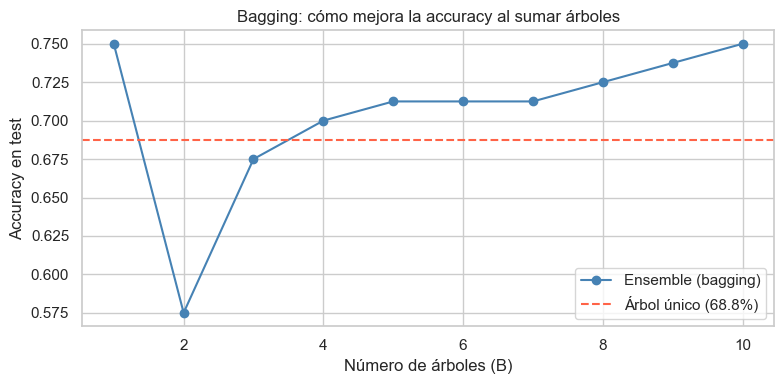


Árbol único       : 68.8%
Ensemble (B=10)   : 75.0%


In [5]:
B = 10
votos = np.zeros((B, len(X_test)), dtype=int)

for b in range(B):
    idx = rng.integers(0, len(X_train), size=len(X_train))
    X_boot, y_boot = X_train[idx], y_train[idx]
    clf = DecisionTreeClassifier(max_depth=4, random_state=b)
    clf.fit(X_boot, y_boot)
    votos[b] = clf.predict(X_test)

# Voto por mayoría acumulativo (1 árbol, 2 árboles, ..., B árboles)
accs_acumulativas = []
for k in range(1, B + 1):
    prediccion_k = (votos[:k].mean(axis=0) >= 0.5).astype(int)
    accs_acumulativas.append(accuracy_score(y_test, prediccion_k))

# Árbol único para comparar
clf_unico = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_unico.fit(X_train, y_train)
acc_unico = accuracy_score(y_test, clf_unico.predict(X_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, B + 1), accs_acumulativas, marker="o", color="steelblue", label="Ensemble (bagging)")
ax.axhline(acc_unico, color="tomato", linestyle="--", label=f"Árbol único ({acc_unico:.1%})")
ax.set_xlabel("Número de árboles (B)")
ax.set_ylabel("Accuracy en test")
ax.set_title("Bagging: cómo mejora la accuracy al sumar árboles")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nÁrbol único       : {acc_unico:.1%}")
print(f"Ensemble (B={B})   : {accs_acumulativas[-1]:.1%}")